In [1]:
# notebook to figure out what the hell is going on with COSMIC
# since v2
# we have:
# fixed the exon file.
# here will establish the final exon intersections
# run vep
# and generate a lookup table for the annotation table for final filtering/analysis

In [37]:
# import packages
import pprint
import pandas as pd
import pybedtools
import os
import requests
import time
import seaborn as sns
from collections import Counter
import matplotlib.pyplot as plt

In [38]:
### USE PROTEIN CODING + SPLICE, TO BE CONSISTENT WITH ALL OTHER ANALYSES, WE CAN PARSE THEM OUT POST ANNOTATION ###

In [3]:
# store path to raw gencode file as a variable for checking
gencode_v44 = '/projects/tewhey-lab/buttsj/genomes/gencode.v44.basic.annotation.gff3.gz'

In [4]:
# open each bed file
# cosmic variants
cosmic_bed = pybedtools.BedTool('../processed_data/all.cosmic.v98.autosome.with.10bp.indels.bed')
# corrected exons + pad
exonsWithPad = pybedtools.BedTool('../raw_data/archive2/gencode.v44.protein.coding.exons.splice.autosomes.v2.bed')

In [5]:
# get the intersections of everything
#### updated bed ####
padIntersect = cosmic_bed.intersect(exonsWithPad, u=True)

In [6]:
# print summaries
# with pad
print(f'there are {len(padIntersect)} variants that intersect with the corrected gencode v44 exons + splice pads')

there are 522542 variants that intersect with the corrected gencode v44 exons + splice pads


In [7]:
# open predictions/full dataframe
allCosmic = pd.read_csv('../processed_data/all.cosmic.v98.autosome.with.10bp.indels.annotated.017.021126.tsv', sep = '\t')

In [8]:
# define a function to convert overlapping variants to a vcf from the full dataset
def bedVariants2vcf (cosmicDF,
                     intersectBed):
    # get the IDs from the intersection
    varIDs = intersectBed.to_dataframe()['name'].tolist()
    # filter the full cosmic df for only those variants
    intersectVars = cosmicDF[cosmicDF['id'].isin(varIDs)].copy()
    # let the VCF begin
    intersectVCF = pd.DataFrame({
        '#CHROM' : intersectVars['chrom'],
        'POS' : intersectVars['pos'],
        'ID' : intersectVars['id'],
        'REF' : intersectVars['ref'],
        'ALT' : intersectVars['alt'],
        'QUAL' : ['.' for i in range(len(intersectVars))],
        'FILTER' : ['.' for i in range(len(intersectVars))],
        'INFO' : ['.' for i in range(len(intersectVars))]
    }).sort_values(by=['#CHROM', 'POS'], ascending = True)
    return intersectVCF

In [9]:
# get the VCFs for all intersections above
# exon + pad
padIntersect_VCF = bedVariants2vcf(
    allCosmic,
    padIntersect
)

In [10]:
padIntersect_VCF.head()

,#CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO
2301001,chr1,926008,COSV59703864,C,A,.,.,.
2301002,chr1,926010,COSV59704909,G,C,.,.,.
2301008,chr1,930159,COSV104639714,G,A,.,.,.
2301009,chr1,930227,COSV104639710,C,T,.,.,.
2301010,chr1,930244,COSV59704210,C,T,.,.,.


In [11]:
# save each to disk
# exon + pad
# padIntersect_VCF.to_csv('../processed_data/vep_vcfs/cosmic_protein_coding_exons_with_pads.vcf', sep = '\t', index = False)

In [12]:
# open the output of the with reg
# padded
paddedWithReg = pd.read_csv(
    '../processed_data/vep_debug_output/cosmic_protein_coding_exons_with_pads_with_regulatory.tsv',
    sep = '\t', 
    comment = '#',
    header = None
)

In [13]:
# updated bed files contain transcript IDs, still need to break off a bit for matching
exonBED = pd.read_csv( # opening the splice containing bed file, shouldn't matter which for this
    '../raw_data/archive2/gencode.v44.protein.coding.exons.splice.autosomes.v2.bed',
    sep = '\t',
    header = None
)
exonBED.loc[:, 'transcriptID'] = [i.split('_')[1]. split('.')[0] for i in exonBED[6]]

In [14]:
exonBED.head()

,0,1,2,3,4,5,6,transcriptID
0,chr1,65418,65439,OR4F5,0,+,ENSG00000186092.7_ENST00000641515.2_OR4F5,ENST00000641515
1,chr1,65499,65579,OR4F5,0,+,ENSG00000186092.7_ENST00000641515.2_OR4F5,ENST00000641515
2,chr1,69016,71585,OR4F5,0,+,ENSG00000186092.7_ENST00000641515.2_OR4F5,ENST00000641515
3,chr1,450739,451678,OR4F29,0,-,ENSG00000284733.2_ENST00000426406.4_OR4F29,ENST00000426406
4,chr1,685715,686654,OR4F16,0,-,ENSG00000284662.2_ENST00000332831.5_OR4F16,ENST00000332831


In [15]:
print(exonBED['transcriptID'].isna().value_counts())

transcriptID
False    194642
Name: count, dtype: int64


In [16]:
# okay let's see how how many features intersect with our exon calls
# filter with the transcript ids
# pad + reg
paddedWithRegCorrectedExons = paddedWithReg[paddedWithReg[4].isin(list(exonBED['transcriptID'].unique()))]

In [17]:
len(paddedWithRegCorrectedExons)

576405

In [18]:
paddedWithRegCorrectedExons.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12
2,COSV59703864,chr1:926008,A,ENSG00000187634,ENST00000616016,Transcript,missense_variant,-,YES,ENST00000618181,-,MODERATE,-
12,COSV59704909,chr1:926010,C,ENSG00000187634,ENST00000616016,Transcript,synonymous_variant,-,YES,ENST00000618181,-,LOW,-
23,COSV104639714,chr1:930159,A,ENSG00000187634,ENST00000616016,Transcript,missense_variant,-,YES,ENST00000341065,-,MODERATE,-
33,COSV104639710,chr1:930227,T,ENSG00000187634,ENST00000616016,Transcript,missense_variant,-,YES,ENST00000341065,-,MODERATE,-
43,COSV59704210,chr1:930244,T,ENSG00000187634,ENST00000616016,Transcript,synonymous_variant,-,YES,ENST00000341065,-,LOW,-


In [19]:
# group the calls by variant id
# pad + reg
paddedWithRegCorrectedExons_grouped = paddedWithRegCorrectedExons.groupby(0).agg({
    1 : 'first', # chromosome + position
    2 : 'first', # alt variant
    3 : lambda x: ','.join(x[x != '-'].unique().astype(str)), # stable id of gene
    4 : lambda x: ','.join(x[x != '-'].unique().astype(str)), # transcript id
    5 : lambda x: ','.join(x[x != '-'].unique().astype(str)), # feature_type
    6 : lambda x: ','.join(x[x != '-'].unique().astype(str)), # consequence
    8 : lambda x: ','.join(x[x != '-'].unique().astype(str)), # canonical
    9 : lambda x: ','.join(x[x != '-'].unique().astype(str)), # nearest transcript
    11 : lambda x: ','.join(x[x != '-'].unique().astype(str)), # predicted impact
}).reset_index()

In [20]:
len(paddedWithRegCorrectedExons_grouped)

522542

In [21]:
# check all variant IDs are present in VEP
# pad + reg
paddedWithRegMissingVars = list(set(padIntersect.to_dataframe()['name']) - set(paddedWithRegCorrectedExons_grouped[0].unique()))
print(f'there are {len(paddedWithRegMissingVars)} variants that do not have a VEP annotation from the padded exon intersection')

there are 0 variants that do not have a VEP annotation from the padded exon intersection


In [39]:
paddedWithRegCorrectedExons_grouped

,0,1,2,3,4,5,6,8,9,11,is_exonic_coding,most_severe,most_severe_impact
0,COSV100000001,chr11:5679890,C,ENSG00000132256,ENST00000380034,Transcript,synonymous_variant,YES,ENST00000438025,LOW,1,synonymous_variant,LOW
1,COSV100000008,chr12:121856399,A,ENSG00000158104,ENST00000289004,Transcript,synonymous_variant,YES,ENST00000289004,LOW,1,synonymous_variant,LOW
2,COSV100000014,chr12:121846915,A,ENSG00000158104,ENST00000289004,Transcript,missense_variant,YES,ENST00000289004,MODERATE,1,missense_variant,MODERATE
3,COSV100000091,chr6:154089954,C,ENSG00000112038,ENST00000330432,Transcript,missense_variant,YES,ENST00000522555,MODERATE,1,missense_variant,MODERATE
4,COSV100000187,chr12:121854786,A,ENSG00000158104,ENST00000289004,Transcript,missense_variant,YES,ENST00000289004,MODERATE,1,missense_variant,MODERATE
...,...,...,...,...,...,...,...,...,...,...,...,...,...
522537,COSV99999889,chr14:74510104,T,ENSG00000119681,ENST00000261978,Transcript,synonymous_variant,YES,ENST00000556206,LOW,1,synonymous_variant,LOW
522538,COSV99999904,chr11:14475844,C,ENSG00000129083,ENST00000439561,Transcript,synonymous_variant,YES,ENST00000439561,LOW,1,synonymous_variant,LOW
522539,COSV99999990,chr12:121854789,T,ENSG00000158104,ENST00000289004,Transcript,missense_variant,YES,ENST00000289004,MODERATE,1,missense_variant,MODERATE
522540,COSV99999992,chr11:14474532,T,ENSG00000129083,ENST00000439561,Transcript,missense_variant,YES,ENST00000439561,MODERATE,1,missense_variant,MODERATE


In [40]:
# okay let's assign coding to these groupby
def has_exonic_coding(consequences):
    """Check if any consequence in the comma-separated string is exonic coding."""
    EXONIC_CODING = [
        "transcript_ablation", "stop_gained", "frameshift_variant",
        "stop_lost", "start_lost", "inframe_insertion", "inframe_deletion",
        "missense_variant", "protein_altering_variant",
        "incomplete_terminal_codon_variant", "start_retained_variant",
        "stop_retained_variant", "synonymous_variant", "coding_sequence_variant",
    ]
    return any(c.strip() in EXONIC_CODING for c in str(consequences).split(","))

In [41]:
# add exon binary column
# pad + reg
paddedWithRegCorrectedExons_grouped['is_exonic_coding'] = paddedWithRegCorrectedExons_grouped[6].apply(has_exonic_coding).astype(int)

In [42]:
paddedWithRegCorrectedExons_grouped['is_exonic_coding'].sum()

np.int64(445096)

In [43]:
paddedWithRegCorrectedExons_grouped['is_exonic_coding'].sum() / len(paddedWithRegCorrectedExons_grouped)

np.float64(0.8517899039694417)

In [27]:
# add most severe consequence
VEP_SEVERITY = [
    "transcript_ablation",
    "splice_acceptor_variant",
    "splice_donor_variant",
    "stop_gained",
    "frameshift_variant",
    "stop_lost",
    "start_lost",
    "transcript_amplification",
    "inframe_insertion",
    "inframe_deletion",
    "missense_variant",
    "protein_altering_variant",
    "splice_donor_5th_base_variant",
    "splice_region_variant",
    "splice_donor_region_variant",
    "splice_polypyrimidine_tract_variant",
    "incomplete_terminal_codon_variant",
    "start_retained_variant",
    "stop_retained_variant",
    "synonymous_variant",
    "coding_sequence_variant",
    "mature_miRNA_variant",
    "5_prime_UTR_variant",
    "3_prime_UTR_variant",
    "non_coding_transcript_exon_variant",
    "intron_variant",
    "NMD_transcript_variant",
    "non_coding_transcript_variant",
    "upstream_gene_variant",
    "downstream_gene_variant",
    "TFBS_ablation",
    "TFBS_amplification",
    "TF_binding_site_variant",
    "regulatory_region_ablation",
    "regulatory_region_amplification",
    "feature_elongation",
    "regulatory_region_variant",
    "feature_truncation",
    "intergenic_variant",
]

# Lower index = more severe
SEVERITY_RANK = {term: i for i, term in enumerate(VEP_SEVERITY)}

def most_severe(consequences):
    """Return the most severe consequence from a comma-separated string."""
    terms = [c.strip() for c in str(consequences).split(",")]
    ranked = sorted(terms, key=lambda t: SEVERITY_RANK.get(t, 999))
    return ranked[0]

In [28]:
# add most severe annotation
# pad + reg
paddedWithRegCorrectedExons_grouped['most_severe'] = paddedWithRegCorrectedExons_grouped[6].apply(most_severe)

In [29]:
# add impact
IMPACT_MAP = {
    "transcript_ablation": "HIGH",
    "splice_acceptor_variant": "HIGH",
    "splice_donor_variant": "HIGH",
    "stop_gained": "HIGH",
    "frameshift_variant": "HIGH",
    "stop_lost": "HIGH",
    "start_lost": "HIGH",
    "transcript_amplification": "HIGH",
    "inframe_insertion": "MODERATE",
    "inframe_deletion": "MODERATE",
    "missense_variant": "MODERATE",
    "protein_altering_variant": "MODERATE",
    "splice_donor_5th_base_variant": "LOW",
    "splice_region_variant": "LOW",
    "splice_donor_region_variant": "LOW",
    "splice_polypyrimidine_tract_variant": "LOW",
    "incomplete_terminal_codon_variant": "LOW",
    "start_retained_variant": "LOW",
    "stop_retained_variant": "LOW",
    "synonymous_variant": "LOW",
    "coding_sequence_variant": "LOW",
    "mature_miRNA_variant": "MODIFIER",
    "5_prime_UTR_variant": "MODIFIER",
    "3_prime_UTR_variant": "MODIFIER",
    "non_coding_transcript_exon_variant": "MODIFIER",
    "intron_variant": "MODIFIER",
    "NMD_transcript_variant": "MODIFIER",
    "non_coding_transcript_variant": "MODIFIER",
    "upstream_gene_variant": "MODIFIER",
    "downstream_gene_variant": "MODIFIER",
    "TFBS_ablation": "MODIFIER",
    "TFBS_amplification": "MODIFIER",
    "TF_binding_site_variant": "MODIFIER",
    "regulatory_region_ablation": "MODERATE",
    "regulatory_region_amplification": "MODIFIER",
    "feature_elongation": "MODIFIER",
    "regulatory_region_variant": "MODIFIER",
    "feature_truncation": "MODIFIER",
    "intergenic_variant": "MODIFIER",
}
# pad + reg
paddedWithRegCorrectedExons_grouped['most_severe_impact'] = paddedWithRegCorrectedExons_grouped['most_severe'].map(IMPACT_MAP)

In [30]:
# color the bar plot by coding/nocoding, make palette
codingPalette = {
    1 : 'firebrick',
    0 : 'cadetblue'
}

In [31]:
len(paddedWithRegCorrectedExons_grouped)

522542

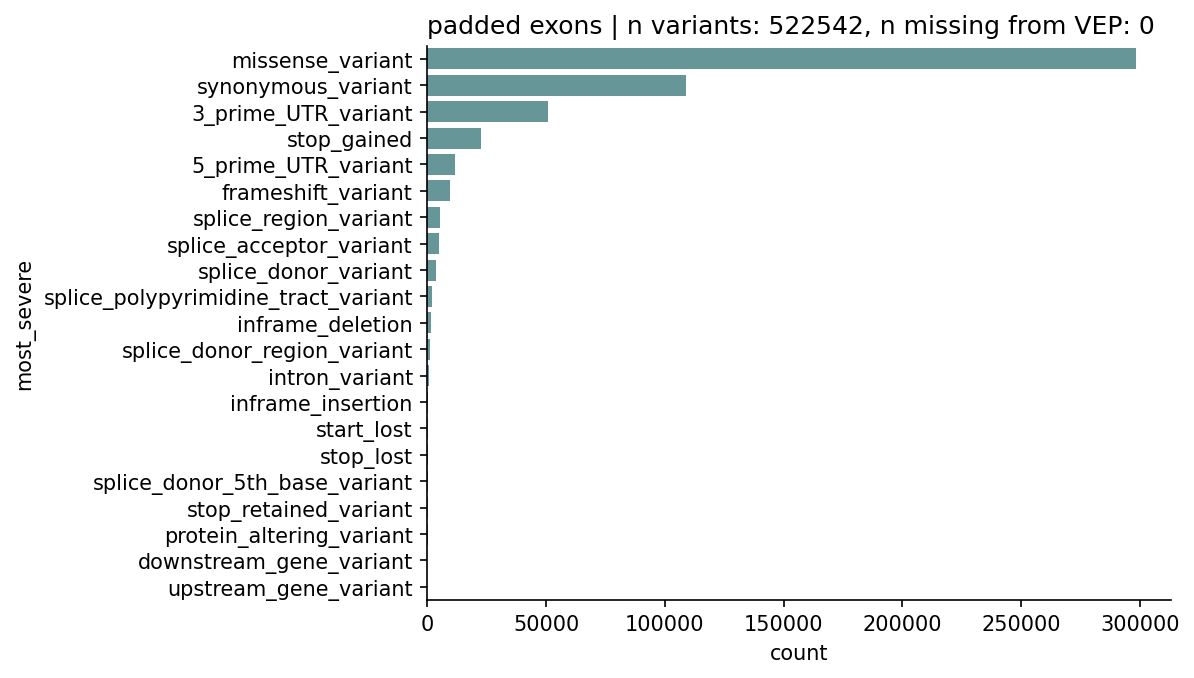

In [32]:
# plot the count of the most severe annotation for each
# pad + reg
plt.figure(dpi=150)
sns.countplot(
    paddedWithRegCorrectedExons_grouped['most_severe'],
    order = paddedWithRegCorrectedExons_grouped['most_severe'].value_counts().index,
    color = 'cadetblue'
)
plt.title(f'padded exons | n variants: {len(paddedWithRegCorrectedExons_grouped)}, n missing from VEP: {len(paddedWithRegMissingVars)}', loc='left')
sns.despine()

In [33]:
Counter(paddedWithRegCorrectedExons_grouped['most_severe'])

Counter({'missense_variant': 298376,
         'synonymous_variant': 109030,
         '3_prime_UTR_variant': 50701,
         'stop_gained': 22473,
         '5_prime_UTR_variant': 11671,
         'frameshift_variant': 9703,
         'splice_region_variant': 5259,
         'splice_acceptor_variant': 4871,
         'splice_donor_variant': 3488,
         'splice_polypyrimidine_tract_variant': 1949,
         'inframe_deletion': 1466,
         'splice_donor_region_variant': 1187,
         'intron_variant': 553,
         'inframe_insertion': 451,
         'start_lost': 441,
         'stop_lost': 376,
         'splice_donor_5th_base_variant': 322,
         'stop_retained_variant': 137,
         'protein_altering_variant': 84,
         'downstream_gene_variant': 2,
         'upstream_gene_variant': 2})

In [36]:
# great. everything seems accounted for let's go ahead and save a df with the cosmic id and vep consequence for annotating the main DF for analysis
cosmicVEP_consequence = pd.DataFrame({
    'cosmic_id' : paddedWithRegCorrectedExons_grouped[0],
    'vep_most_severe' : paddedWithRegCorrectedExons_grouped['most_severe']
})
# cosmicVEP_consequence.to_csv('../processed_data/ensembl_vep_exon_overlap_most_severe.txt',
#                              sep = '\t',
#                              index = False)

In [ ]:
### SCRATCH ###